# CW1 - Multimodal IMDB Analysis with Keras

## Introduction

In this assignment you will be provided a dataset containing a selection of films together with their posters in JPEG image format and their overviews in text format from the Internet Movie Database.

![Example](https://i.ibb.co/J3trT62/Screenshot-2024-09-22-214753.png)

You will be analysing this dataset by implementing and training two models: a **CNN** and an **LSTM**.

The CNN must classify film posters by the genre. Independently, the LSTM must classify film overviews by the genre. Finally, you will evaluate and critically comment your results in a short report. (Which of the two models was better at classifying films?)

## Structure of the assignment

This assignment is broken up into sections and you need to complete each section successively. The sections are the following:

1. Data Processing

  1.a. Image processing of the posters

  1.b. Natural language processing of the overviews

2. Definition of the models

  2.a. CNN for the posters

  2.b. LSTM for the overviews

3. Training of the models
4. Evaluation of the models

In addition to this coding exercise, you must write a **2-3 pages** report analysing and critically evaluating your model's results. Marks for the report will be awarded for depth of analysis and critical thinking skills. You should consider how well your model performs and WHY it does that—give specific examples and comment on their importance.

In [1]:
# Enter your module imports here, some modules are already provided

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
import pathlib
import pandas as pd
from sklearn import model_selection
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.optimizers import Adam
from keras.metrics import Precision, Recall
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import Embedding
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import ModelCheckpoint




In [2]:
# CodeGrade Tag Init1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Processing

Warning: running the following cell can take some time.


In [3]:
# CodeGrade Tag Init2
# Do not edit, remove, or copy this cell

# This code will copy the images from your google drive into the colab file
# storage. Make sure the dataset is unzipped in your drive folder.
! mkdir /tmp/Multimodal_IMDB_dataset
! rsync -ah --info=progress2 /content/drive/MyDrive/Multimodal_IMDB_dataset/Images /tmp/Multimodal_IMDB_dataset/


        191.90M 100%  737.15kB/s    0:04:14 (xfr#7906, to-chk=0/7907)


In [4]:
# CodeGrade Tag Init3
# Do not edit, remove, or copy this cell

# Load the csv with the sample IDs and genres
csv_loc = "/content/drive/MyDrive/Multimodal_IMDB_dataset/IMDB_overview_genres.csv"
dataset = pd.read_csv(csv_loc)

# Split the dataset into training and testing
data_train, data_test = model_selection.train_test_split(dataset, test_size=0.2)

# Convert the labels to arrays
labels_train = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')
labels_test = np.array(data_test.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')

# List of the genre names
genres = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1).columns)

# List of overviews
overviews_train = np.array(data_train['Overview'])
overviews_test = np.array(data_test['Overview'])

# Build the file locations for the images
img_loc = "/tmp/Multimodal_IMDB_dataset/Images"

img_locs_train = np.array([[img_loc + '/' + id + '.jpg' for id in data_train['Id']]])
img_locs_test = [[img_loc + '/' + id + '.jpg' for id in data_test['Id']]]

# This function is provided to read in the image files from the folder
def parse_image(filename, label):
  image = tf.io.read_file(filename)
  image = tf.io.decode_jpeg(image)
  return image, label


### 1.a. Image processing of the posters

In [5]:
# CodeGrade Tag Init4
# Do not edit, remove, or copy this cell

# Create the initial datasets of film posters
list_posters_train_ds = tf.data.Dataset.from_tensor_slices((img_locs_train[0], labels_train))
list_posters_valid_ds = tf.data.Dataset.from_tensor_slices((img_locs_test[0], labels_test))

* Create a function called ```img_process``` that converts the images to float32 datatype and resizes them to 64x64 pixels

In [7]:
# CodeGrade Tag Ex1a-i
### Create a function called img_process that converts the images to
### float32 datatype and resizes them to 64x64 pixels

def img_process(image, label):

    """
    Prepares an image for processing by converting it to a float32 tensor and resizing it to 64x64 pixels.
    Args:
        image: The input image tensor.
        label: The corresponding label associated with the image.
    Returns:
         A tuple containing the processed image and its label.
    """
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [64,64])
    return image, label

* **Using the ``tf.data`` API, load in the training and validation data for the posters. Be mindful of efficient data processing good practice to minimise the time it takes to load the data.**

In [8]:
# CodeGrade Tag Ex1a-ii
### Use the parse_image and img_process functions to construct the training and
### validation datasets. You should utilise good practice in optimising the
### dataset loading. Use a batch size of 64.

posters_train_ds = (
    list_posters_train_ds
    .map(parse_image, num_parallel_calls = tf.data.AUTOTUNE)
    .batch(64)
    .map(img_process, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(buffer_size=1000)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

posters_valid_ds = (
    list_posters_valid_ds
    .map(parse_image, num_parallel_calls = tf.data.AUTOTUNE)
    .batch(64)
    .map(img_process, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

### 1.b. Natural Language processing of the overviews

In [9]:
# CodeGrade Tag Init5
# Do not edit, remove, or copy this cell

# Create the initial datasets of the film overviews
list_overviews_train_ds = tf.data.Dataset.from_tensor_slices((overviews_train, labels_train))
list_overviews_valid_ds = tf.data.Dataset.from_tensor_slices((overviews_test, labels_test))

* **Using the ``tf.data`` API, load in the training and validation data for the overviews.**

In [10]:
# CodeGrade Tag Ex1b-i
### Construct the training and validation datasets. Use a batch size of 64.

overviews_train_ds = (
    list_overviews_train_ds
    .shuffle(buffer_size=1000)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

overviews_valid_ds = (
    list_overviews_valid_ds
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

* Build the vocabulary of the model by calling the ``encoder.adapt()`` method on the film overviews train data.

In [11]:
# CodeGrade Tag Ex1b-ii
### Build the vocabulary of the model by calling the encoder.adapt() method on
### the film overviews train data.

VOCAB_SIZE = 10000

encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=100
)

# Adapt the encoder to the training data
encoder.adapt(overviews_train_ds.map(lambda overview, label: overview))


* Print the first 200 words of the vocabulary you obtained.

In [12]:
# CodeGrade Tag Ex1b-iii
### Print the first 200 words of the vocabulary you obtained.

# Get the vocabulary from the encoder
vocabulary = encoder.get_vocabulary()

# Print the first 200 words
print("First 200 words in the vocabulary:")
print(vocabulary[:200])

First 200 words in the vocabulary:
['', '[UNK]', 'a', 'the', 'to', 'of', 'and', 'in', 'his', 'is', 'an', 'with', 'her', 'for', 'on', 'their', 'he', 'who', 'by', 'from', 'when', 'as', 'that', 'after', 'young', 'life', 'they', 'man', 'at', 'him', 'two', 'are', 'new', 'but', 'she', 'has', 'into', 'up', 'love', 'woman', 'family', 'out', 'one', 'find', 'friends', 'must', 'finds', 'it', 'be', 'world', 'story', 'them', 'school', 'about', 'where', 'while', 'group', 'have', 'girl', 'home', 'years', 'wife', 'father', 'lives', 'town', 'war', 'city', 'becomes', 'three', 'get', 'help', 'during', 'back', 'all', 'himself', 'boy', 'which', 'only', 'gets', 'son', 'time', 'york', 'high', 'murder', 'against', 'team', 'other', 'down', 'its', 'between', 'american', 'former', 'own', 'falls', 'mother', 'before', 'being', 'tries', 'takes', 'will', 'small', 'police', 'old', 'become', 'order', 'goes', 'daughter', 'take', 'friend', 'through', 'this', 'set', 'death', 'together', 'save', 'can', 'college', 'was', '

# 2. Definition of the models

### 2.a. CNN

**Using the Keras Functional API, create a convolutional neural network with the architecture shown in the model summary below.**

**A few important points to consider:**

* Call the convolutional layers and the first dense layer should have ReLU activation functions. The output layer should have a Sigmoid activation function.
* Pay attention to the output shapes and the number of partmeters for each layer, as these give indications as to the correct settings for the number of filters, kernel size, stride length and padding.
* Use the layer names provided in the summary in your model.
* For the dropout layers, use a dropout rate of 0.2 after the convolutional layers and 0.5 after the dense layers.


```
# Model Summary

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
=================================================================
 Input (InputLayer)          [(None, 64, 64, 3)]       0         
                                                                 
 Conv0 (Conv2D)              (None, 32, 32, 16)        448       
                                                                 
 Drop1 (Dropout)             (None, 32, 32, 16)        0         
                                                                 
 Conv1 (Conv2D)              (None, 32, 32, 32)        4640      
                                                                 
 Conv2 (Conv2D)              (None, 32, 32, 32)        9248      
                                                                 
 Drop2 (Dropout)             (None, 32, 32, 32)        0         
                                                                 
 Pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 Conv3 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 Conv4 (Conv2D)              (None, 16, 16, 64)        36928     
                                                                 
 Drop3 (Dropout)             (None, 16, 16, 64)        0         
                                                                 
 Pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 Conv5 (Conv2D)              (None, 8, 8, 128)         73856     
                                                                 
 Conv6 (Conv2D)              (None, 8, 8, 128)         147584    
                                                                 
 Drop4 (Dropout)             (None, 8, 8, 128)         0         
                                                                 
 Pool3 (MaxPooling2D)        (None, 4, 4, 128)         0         
                                                                 
 Flat (Flatten)              (None, 2048)              0         
                                                                 
 FC1 (Dense)                 (None, 1024)              2098176   
                                                                 
 Drop5 (Dropout)             (None, 1024)              0         
                                                                 
 FC2 (Dense)                 (None, 1024)              1049600   
                                                                 
 Drop6 (Dropout)             (None, 1024)              0         
                                                                 
 Output (Dense)              (None, 25)                25625     
                                                                 
=================================================================
Total params: 3464601 (13.22 MB)
Trainable params: 3464601 (13.22 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


```



In [13]:
# CodeGrade Tag Ex2a-i
### Define the model using the Keras Functional API. Use the summary above as a
### guide for the model parameters. You will need to define the filters/units of
### the layers correctly, as well as the kernel size, stride length and padding
### of the convolutional layers.

def build_cnn_model():
    # Input layer
    Inp = layers.Input((64, 64, 3), dtype='float32', name='Input')

    # First convolutional block
    Conv0 = layers.Conv2D(16, (3, 3), strides=2, activation='relu', padding='same', name='Conv0')(Inp)
    Drop1 = layers.Dropout(0.2, name='Drop1')(Conv0)

    # Second convolutional block
    Conv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='Conv1')(Drop1)
    Conv2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='Conv2')(Conv1)
    Drop2 = layers.Dropout(0.2, name='Drop2')(Conv2)
    Pool1 = layers.MaxPooling2D(pool_size=(2, 2), name='Pool1')(Drop2)

    # Third convolutional block
    Conv3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='Conv3')(Pool1)
    Conv4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='Conv4')(Conv3)
    Drop3 = layers.Dropout(0.2, name='Drop3')(Conv4)
    Pool2 = layers.MaxPooling2D(pool_size=(2, 2), name='Pool2')(Drop3)

    # Fourth convolutional block
    Conv5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='Conv5')(Pool2)
    Conv6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='Conv6')(Conv5)
    Drop4 = layers.Dropout(0.2, name='Drop4')(Conv6)
    Pool3 = layers.MaxPooling2D(pool_size=(2, 2), name='Pool3')(Drop4)

    # Fully connected layers
    Flat = layers.Flatten(name='Flat')(Pool3)
    FC1 = layers.Dense(1024, activation='relu', name='FC1')(Flat)
    Drop5 = layers.Dropout(0.5, name='Drop5')(FC1)
    FC2 = layers.Dense(1024, activation='relu', name='FC2')(Drop5)
    Drop6 = layers.Dropout(0.5, name='Drop6')(FC2)

    # Output layer
    Output = layers.Dense(25, activation='sigmoid', name='Output')(Drop6)

    # Define the model
    model = models.Model(inputs=Inp, outputs=Output, name="CNN_Model")
    return model


cnn_model = build_cnn_model()


* Print the model summary and confirm it has the same architecture as the one provided.

In [14]:
# CodeGrade Tag Ex2a-ii
### Print the model summary and confirm it has the same architecture as the one
### provided.

cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)                   │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv0 (Conv2D)                       │ (None, 32, 32, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop1 (Dropout)                      │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv1 (Conv2D)                       │ (None, 32, 32, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop2 (Dropout)                      │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool1 (MaxPooling2D)                 │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop3 (Dropout)                      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool2 (MaxPooling2D)                 │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv5 (Conv2D)                       │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv6 (Conv2D)                       │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop4 (Dropout)                      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool3 (MaxPooling2D)                 │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Flat (Flatten)                       │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ FC1 (Dense)                          │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop5 (Dropout)                      │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ FC2 (Dense)                          │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Drop6 (Dropout)                      │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 25)                  │          25,625 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 3,464,601 (13.22 MB)

 Trainable params: 3,464,601 (13.22 MB)

 Non-trainable params: 0 (0.00 B)

* **Compile the model using the Adam Optimizer with a learning rate of ```1e-4``` and ```binary crossentropy``` loss function. For the metrics, use the ``Precision`` and ``Recall`` functions.**

In [15]:
# CodeGrade Tag Ex2a-iii
### Compile the model using the Adam Optimizer with a learning rate of 1e-4 and
### binary crossentropy loss function. For the metrics, use the Precision and
### Recall functions.

cnn_model.compile(
     optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[Precision(), Recall()]
    )

### 2.b. LSTM model

* Set up the embedding layer by using ```tf.keras.layers.Embedding```. The ```input_dim``` is the length of the vocab, and the ```output_dim``` must be **265**. You should also set ```mask_zero=True```.

In [16]:
# CodeGrade Tag Ex2b-i
### Set up the embedding layer. The input_dim is the length of the vocab, and
### the output_dim must be 256. You should also set mask_zero=True.

embedder = tf.keras.layers.Embedding(
    input_dim=len(encoder.get_vocabulary()),
    output_dim=256,
    mask_zero=True,
    name="Embedding_Layer"
)

* Use ```tf.keras.Sequential``` to build a keras sequential model, with the following layers:



  1.   encoder
  2.   embedder
  3.   biLSTM layer with 256 units, dropout 0.5, recurrent dropout 0.2 (make sure to use the right ```return_sequences``` parametre to be able to stack this layer with the following BiLSTM)
  4.   biLSTM layer with 128 units, dropout 0.5, recurrent dropout 0.2
  5.   dense layer with 128 units and relu activation function
  6.   dropout with rate 0.8
  7.   dense output layer with 25 units and sigmoid activation function



In [17]:
# CodeGrade Tag Ex2b-ii
### Build a keras sequential model, with the layers provided above.

lstm_model = Sequential([
    encoder,
    embedder,
    Bidirectional(LSTM(256, dropout=0.5, recurrent_dropout=0.2, return_sequences=True), name="BiLSTM_1"),
    Bidirectional(LSTM(128, dropout=0.5, recurrent_dropout=0.2), name="BiLSTM_2"),
    Dense(128, activation='relu', name="Dense_128"),
    Dropout(0.8, name="Dropout_0.8"),
    Dense(25, activation='sigmoid', name="Output_Layer")
], name="LSTM_Model")

lstm_model.build((None,))

* Print the model summary and confirm is has the same architecture as the outline provided above.

In [18]:
# CodeGrade Tag Ex2b-iii
### Print the model summary and confirm is has the same architecture as the
### outline provided above.

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ (None, 100)                 │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Embedding_Layer (Embedding)          │ (None, 100, 256)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BiLSTM_1 (Bidirectional)             │ (None, 100, 512)            │       1,050,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BiLSTM_2 (Bidirectional)             │ (None, 256)                 │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_128 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_0.8 (Dropout)                │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,303,129 (16.42 MB)

 Trainable params: 4,303,129 (16.42 MB)

 Non-trainable params: 0 (0.00 B)

* Compile the model with binary crossentropy loss and the adam optimizer. For the metrics, use the Precision and Recall functions.

In [19]:
# CodeGrade Tag Ex2b-iv
### Compile the model with binary crossentropy loss, the adam optimizer, with
### the precision and recall metrics

lstm_model.compile(
     loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
     optimizer=tf.keras.optimizers.Adam(1e-4),
     metrics=[Precision(name='precision'), Recall(name='recall')]
)


# 3. Training of the models

* **For each model, create a Checkpoint Callback that saves the weights of the best performing epoch, based on the validation loss.**

In [20]:
# CodeGrade Tag Ex3a-i
### Create two ModelCheckpoint callbacks to store the bext weights from each
### model, both based on the validation loss.

checkpoint_cnn_filepath = '/content/checkpoint_cnn.weights.h5'
checkpoint_lstm_filepath = '/content/checkpoint_lstm.weights.h5'

checkpoint_cnn_callback =  ModelCheckpoint(
    filepath=checkpoint_cnn_filepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,  # Allow saving weights in .h5 format
    mode='min',
    verbose=1
)

checkpoint_lstm_callback =  ModelCheckpoint(
    filepath=checkpoint_lstm_filepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,  # Allow saving weights in .h5 format
    mode='min',
    verbose=1
)

* **Create a Learning Rate Scheduler Callback that utilises the provided function to decrease the learning rate during training.**

In [21]:
# CodeGrade Tag Ex3a-ii
### Using the function provided, create a LearningRateScheduler callback, call
### it "lr_callback"

def scheduler(epoch, lr):
    if epoch < 10:
        return float(lr)
    else:
        return float(lr * tf.math.exp(-0.01))

lr_callback = LearningRateScheduler(scheduler, verbose=1)




### 3.a. CNN training

* **Train the CNN model for 40 epochs, using the callbacks you made previously. Store the losses and metrics to use later.**

In [22]:
# CodeGrade Tag Ex3a-iii
### Train the model for 40 epochs, using the callbacks you have created. Store
### the losses and metrics in a history object.

cnn_history = cnn_model.fit(
    posters_train_ds,
    validation_data=posters_valid_ds,
    epochs=40,
    callbacks=[checkpoint_cnn_callback,
               lr_callback],
    verbose=1
    )



Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/40
75/80 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 1.5853 - precision: 0.2064 - recall: 0.3003
Epoch 1: val_loss improved from inf to 0.36881, saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - loss: 1.5172 - precision: 0.2115 - recall: 0.2984 - val_loss: 0.3688 - val_precision: 0.5281 - val_recall: 0.3473 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/40
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2914 - precision: 0.4239 - recall: 0.2543
Epoch 2: val_loss improved from 0.36881 to 0.35936, saving model to /content/checkpoint_cnn.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2912 - precision: 0.4243 - recall: 0.2542 - val_loss: 0.3594 - val_precision: 0.5360 - val_recall: 0.3364 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.9999

* **Train the model for 20 epochs** (this may take several minutes)**, using the callbacks you made previously. Store the losses and metrics to use later.**

In [23]:
# CodeGrade Tag Ex3b-i
# Train the model for 20 epochs.
lstm_history = lstm_model.fit(
    overviews_train_ds,
    validation_data=overviews_valid_ds,
    epochs=20,
    callbacks=[checkpoint_lstm_callback,
               lr_callback],
    verbose=1

                    )


Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - loss: 0.6576 - precision: 0.1148 - recall: 0.3820
Epoch 1: val_loss improved from inf to 0.32542, saving model to /content/checkpoint_lstm.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 55s 562ms/step - loss: 0.6568 - precision: 0.1150 - recall: 0.3815 - val_loss: 0.3254 - val_precision: 0.5000 - val_recall: 3.2982e-04 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - loss: 0.4388 - precision: 0.1768 - recall: 0.2615
Epoch 2: val_loss improved from 0.32542 to 0.27595, saving model to /content/checkpoint_lstm.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 548ms/step - loss: 0.4386 - precision: 0.1770 - recall: 0.2615 - val_loss: 0.2759 - val_precision: 0.5344 - val_recall: 0.2230 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rat

# 4. Evaluation of the models

### 4.a. CNN Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

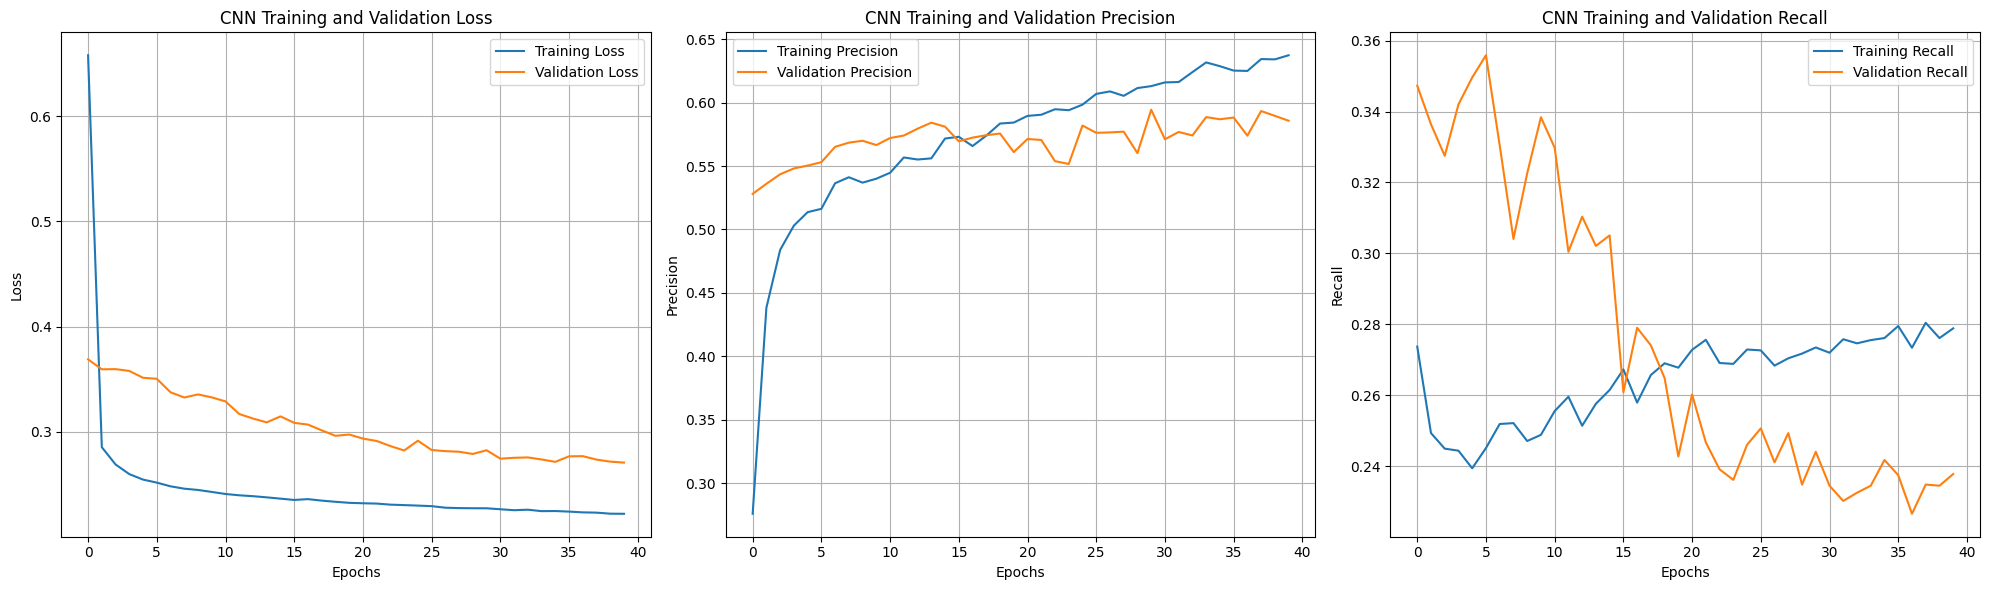

In [28]:
# CodeGrade Tag Ex4a-i

# Creating subplots for Loss, Precision, and Recall
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Plotting training and validation losses
axs[0].plot(cnn_history.history['loss'], label='Training Loss')
axs[0].plot(cnn_history.history['val_loss'], label='Validation Loss')
axs[0].set_title('CNN Training and Validation Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plotting training and validation precision
axs[1].plot(cnn_history.history['precision'], label='Training Precision')
axs[1].plot(cnn_history.history['val_precision'], label='Validation Precision')
axs[1].set_title('CNN Training and Validation Precision')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Precision')
axs[1].legend()
axs[1].grid(True)

# Plotting training and validation recall
axs[2].plot(cnn_history.history['recall'], label='Training Recall')
axs[2].plot(cnn_history.history['val_recall'], label='Validation Recall')
axs[2].set_title('CNN Training and Validation Recall')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel('Recall')
axs[2].legend()
axs[2].grid(True)

# Adjust layout and show
plt.tight_layout()
plt.show()

* **Load the best weights from your model checkpoint, and create plots demonstrating the classification performance for all three classes. Include these plots in your report, and critically evaluate on the performance of the model across the classes.**

### 4.b. LSTM Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.2261 - precision: 0.5965 - recall: 0.2334
LSTM Model Evaluation:
Loss: 0.22717104852199554
Precision: 0.6026936173439026
Recall: 0.23614776134490967


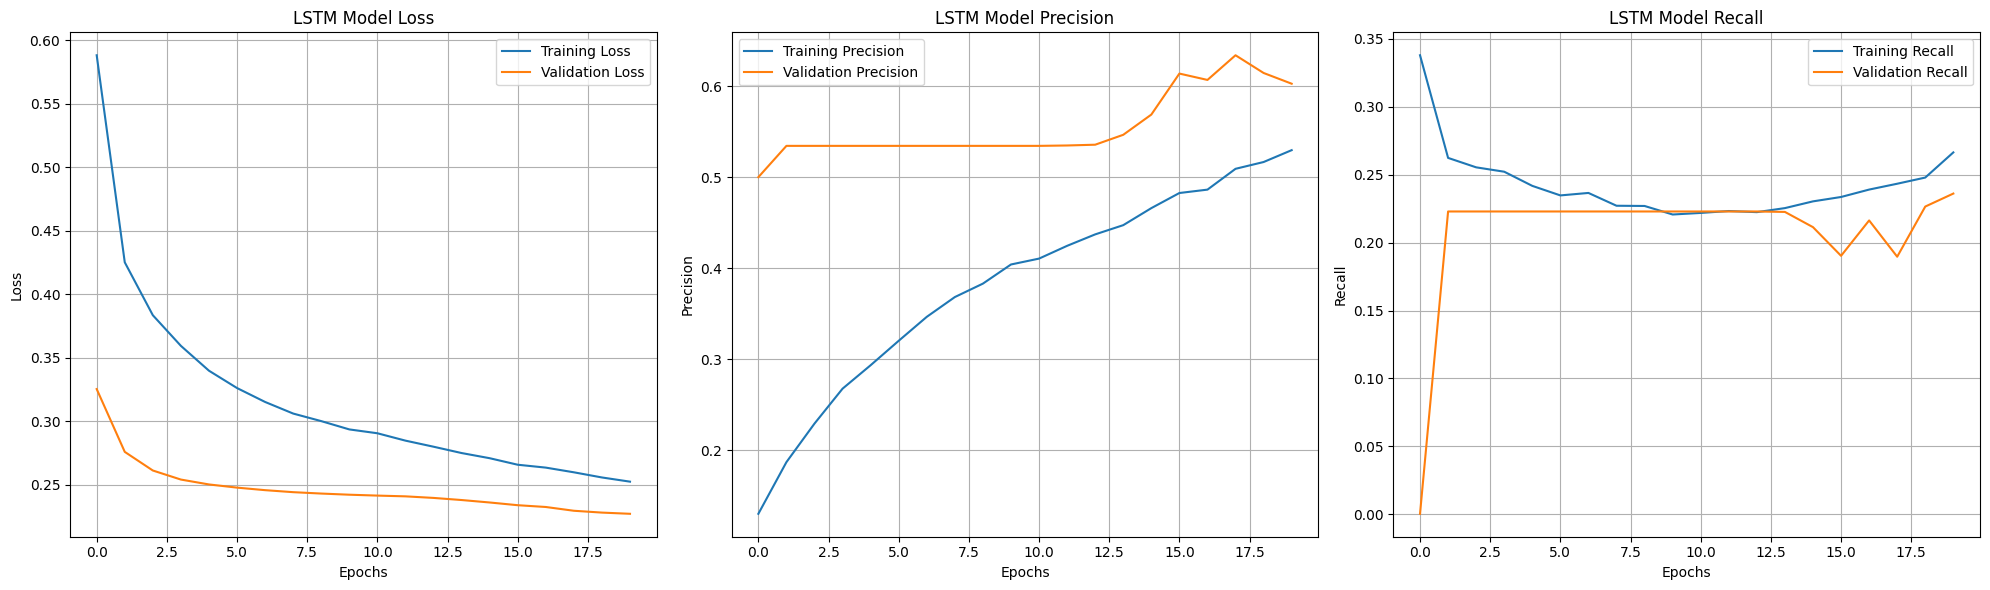


Critical Evaluation:
- The training and validation losses demonstrate steady improvement, with the validation loss improving significantly during the first 10 epochs and stabilizing thereafter. This suggests that the model is learning effectively without overfitting.
- Precision measures the model's ability to avoid false positives, while Recall assesses its ability to detect true positives. Early epochs show lower precision and recall, but these metrics gradually improve, indicating the model's capacity to generalize as training progresses.
- Validation precision and recall stabilize around 0.6 and 0.27, respectively, suggesting moderate performance. However, the recall indicates that the model may miss a significant number of true positives.
- The imbalance in the dataset could be a contributing factor, as some classes may dominate the learning process, leading to biases in the model's predictions.
- To improve performance, techniques such as class balancing, data augmentation, or e

In [26]:
# CodeGrade Tag Ex4b-i

# Load the best weights from the checkpoint
lstm_model.load_weights(checkpoint_lstm_filepath)

# Evaluate the model on the test set
lstm_evaluation = lstm_model.evaluate(overviews_valid_ds, verbose=1)

# Extracting metrics for evaluation
loss, precision, recall = lstm_evaluation

print(f"LSTM Model Evaluation:")
print(f"Loss: {loss}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

# Creating subplots for Loss, Precision, and Recall
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Plotting training and validation losses
axs[0].plot(lstm_history.history['loss'], label='Training Loss')
axs[0].plot(lstm_history.history['val_loss'], label='Validation Loss')
axs[0].set_title('LSTM Model Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid()

# Plotting training and validation precision
axs[1].plot(lstm_history.history['precision'], label='Training Precision')
axs[1].plot(lstm_history.history['val_precision'], label='Validation Precision')
axs[1].set_title('LSTM Model Precision')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Precision')
axs[1].legend()
axs[1].grid()

# Plotting training and validation recall
axs[2].plot(lstm_history.history['recall'], label='Training Recall')
axs[2].plot(lstm_history.history['val_recall'], label='Validation Recall')
axs[2].set_title('LSTM Model Recall')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel('Recall')
axs[2].legend()
axs[2].grid()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

### 4.c. Produce examples for the report

* First, load the best weights from your checkpoints of both your models.

* Choose a few films from the dataset, plot their posters and print their overviews. Use these example films to demonstrate the classification performance of the CNN model on their posters and of the LSTM model on their overview.

* Be sure to demonstrate the results of the multi-label classification. Compare, for each example film, the top three most probable genres predicted by the CNN and the top three most probable genres predicted by the LSTM with the ground truth genres.

* Include these examples in your report, and critically evaluate on the performance of the model across the classes.

Best weights loaded for both models.


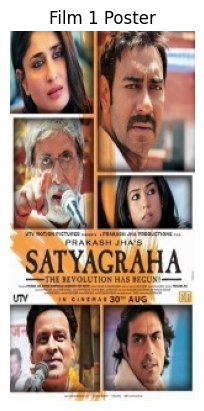

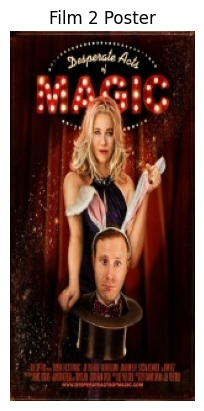

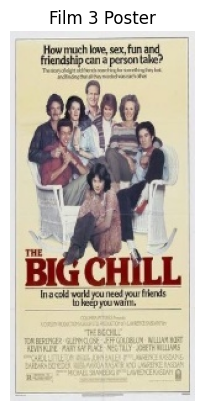

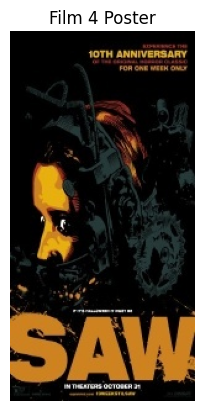

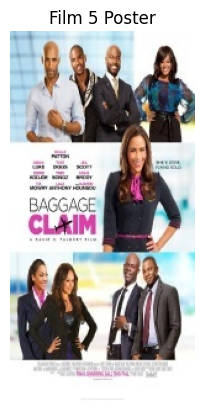

Film 1 Overview:
A corporate go-getter sees his priorities shift when a personal tragedy brings him face-to-face with political corruption.

Film 2 Overview:
A magician competes in an international magic competition where he goes head to head with a female street magician he has fallen in love with. This film shows great magic performed by a ...

Film 3 Overview:
A group of seven former college friends gather for a week-end reunion at a South Carolina vacation home after the funeral of another of their college friends.

Film 4 Overview:
Two strangers, who awaken in a room with no recollection of how they got there, soon discover they're pawns in a deadly game perpetrated by a notorious serial killer.

Film 5 Overview:
Pledging to keep herself from being the oldest and the only woman in her entire family never to wed, Montana embarks on a thirty-day, thirty-thousand-mile expedition to charm a potential suitor into becoming her fiancé.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step
1/1 ━━━━━━━━

In [27]:
# CodeGrade Tag Ex4c

# Load the best weights from the checkpoints stored in .h5 files
cnn_model.load_weights('checkpoint_cnn.weights.h5')  # Adjusted to .h5 file
lstm_model.load_weights('checkpoint_lstm.weights.h5')  # Adjusted to .h5 file
print("Best weights loaded for both models.")

# Select a few example films from the test dataset
example_data = data_test.sample(n=5, random_state=42)  # Randomly pick 5 samples
example_posters = example_data['Id'].values
example_overviews = example_data['Overview'].values
ground_truth_genres = labels_test[np.where(data_test.index.isin(example_data.index))]

# Plot Posters
for i, poster_id in enumerate(example_posters):
    image_path = f"/tmp/Multimodal_IMDB_dataset/Images/{poster_id}.jpg"
    image = plt.imread(image_path)
    plt.imshow(image)
    plt.title(f"Film {i+1} Poster")
    plt.axis('off')
    plt.show()

# Print Overviews
for i, overview in enumerate(example_overviews):
    print(f"Film {i+1} Overview:\n{overview}\n")

# Get CNN Predictions
cnn_predictions = []
for poster_id in example_posters:
    image_path = f"/tmp/Multimodal_IMDB_dataset/Images/{poster_id}.jpg"
    image = tf.image.decode_jpeg(tf.io.read_file(image_path))
    image = tf.image.resize(image, [64, 64])
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    image = tf.expand_dims(image, axis=0)      # Add batch dimension
    preds = cnn_model.predict(image)[0]        # Get predictions
    cnn_predictions.append(preds)

# Get LSTM Predictions
lstm_predictions = []
for overview in example_overviews:
    overview = tf.convert_to_tensor([overview])  # Convert to tensor
    preds = lstm_model.predict(overview)[0]      # Get predictions
    lstm_predictions.append(preds)

# Compare Predictions with Ground Truth
for i, (cnn_pred, lstm_pred, true_genres) in enumerate(zip(cnn_predictions, lstm_predictions, ground_truth_genres)):
    print(f"Film {i+1} Results:")

    # CNN Predictions
    cnn_top3_indices = cnn_pred.argsort()[-3:][::-1]
    cnn_top3_genres = genres[cnn_top3_indices]
    cnn_top3_probs = cnn_pred[cnn_top3_indices]
    print(f"  CNN Top 3 Predicted Genres: {list(zip(cnn_top3_genres, cnn_top3_probs))}")

    # LSTM Predictions
    lstm_top3_indices = lstm_pred.argsort()[-3:][::-1]
    lstm_top3_genres = genres[lstm_top3_indices]
    lstm_top3_probs = lstm_pred[lstm_top3_indices]
    print(f"  LSTM Top 3 Predicted Genres: {list(zip(lstm_top3_genres, lstm_top3_probs))}")

    # Ground Truth Genres
    true_genres_names = genres[np.where(true_genres == 1)]
    print(f"  Ground Truth Genres: {true_genres_names}\n")
